In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.parity.tanh import TanhParityTransform
# from src.transforms.parity.polynomial import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

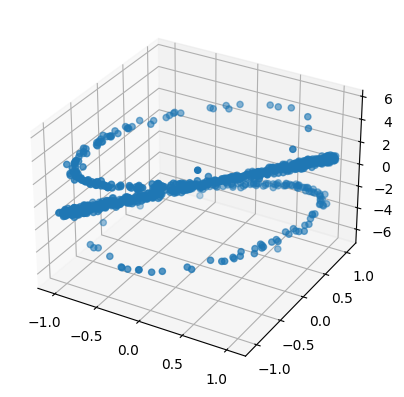

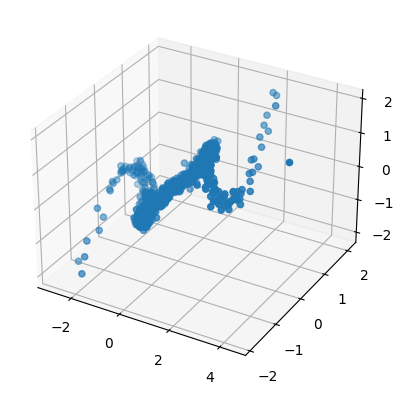

In [2]:
# Construct dataset
def generalised_sinusoid_sampling(dim, latent_dim, num_samples):
    #K the dimension of the manifold
    #N the ambient dimension
    #shearing in the sinusoid formation
    #variances dictate the manifold concentration
    N = dim
    K = latent_dim
    
    # Extract variances for the latent space (manifold) and ambient space
    manifold_variances = 3 * torch.ones(K)
    ambient_variances = 1e-3 * torch.ones(N-K)

    # Sample from the K-dimensional latent space (manifold)
    z_samples = torch.randn(num_samples, K) * torch.sqrt(manifold_variances)

    # Initialize random shears for the off-manifold (N-K) dimensions
    off_manifold_shears = torch.rand(N - K, K) * (2 - 1) + 1  # Random values between [1, 2]

    # Generate the off-manifold samples using the shear vectors and z_samples
    off_manifold_means = []
    for j in range(N - K):
        shear_j = off_manifold_shears[j]  # Get the shear vector for the j-th off-manifold dimension
        off_manifold_mean = torch.sin(z_samples @ shear_j.unsqueeze(1))  # Sinusoidal transformation for off-manifold
        off_manifold_means.append(off_manifold_mean.squeeze(1))  # Squeeze to get correct shape

    # Stack the off-manifold dimensions together
    off_manifold_means = torch.stack(off_manifold_means, dim=1)

    # Generate ambient samples for the remaining (N-K) dimensions
    off_manifold_samples = off_manifold_means + torch.randn(num_samples, N - K) * torch.sqrt(ambient_variances)

    # Combine the manifold and ambient samples
    samples = torch.cat([off_manifold_samples, z_samples], dim=1)
    
    return samples

def random_gaussian_rip(n, m):
    return torch.randn(n, m) / (m**0.5)  # Variance 1/m scaling

dim = 5
num_samples = 1000
noise_level = 0.1

data_clean = generalised_sinusoid_sampling(dim, 1, num_samples)

cor_dim = 3
forward_operator = random_gaussian_rip(cor_dim, dim)

data_train_clean = torch.einsum("nm,Nm->Nn", forward_operator, data_clean) 
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class LinearForward(nn.Module):
    def __init__(self, linear):
        super().__init__()
        self.A = linear

    def forward(self, x):
        return torch.einsum("nm,Nm->Nn", self.A, x) 

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(TanhParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model # TODO make this just with identity transform
def create_conditional_flow_model(dim, cor_dim, n_flows, order, unit_det=False):
    base_dist = distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=nn.Linear(cor_dim, 2 * dim))
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(TanhParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = LinearForward(forward_operator)

n_flows = 6
flow = create_flow_model(dim, n_flows, 2)
prior_diffeo = NFlowVectorDiffeomorphism(dim, flow)

n_layers = 2
c_flow = create_conditional_flow_model(dim, cor_dim, n_flows, 2)
posterior_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=0.1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, real_data_reg=None):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            if real_data_reg is not None:
                log_p_theta_gt = model.phi.nflow.log_prob(data_clean[0:10])
                loss -= real_data_reg * log_p_theta_gt.mean()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [ ]:
# Train the model
n_epochs = 500 #250
real_data_reg = 1.
train(model, train_loader, optimizer, n_epochs, real_data_reg=real_data_reg)

Epoch 1/250, Loss: 72.9550
Epoch 2/250, Loss: 57.4707
Epoch 3/250, Loss: 54.1809
Epoch 4/250, Loss: 45.8598
Epoch 5/250, Loss: 45.9273
Epoch 6/250, Loss: 34.3208
Epoch 7/250, Loss: 32.2366
Epoch 8/250, Loss: 29.8518
Epoch 9/250, Loss: 27.4817
Epoch 10/250, Loss: 24.9799
Epoch 11/250, Loss: 25.4992
Epoch 12/250, Loss: 24.3995
Epoch 13/250, Loss: 23.6102
Epoch 14/250, Loss: 21.5426
Epoch 15/250, Loss: 23.9751
Epoch 16/250, Loss: 20.9785
Epoch 17/250, Loss: 22.4403
Epoch 18/250, Loss: 20.4097
Epoch 19/250, Loss: 20.4565
Epoch 20/250, Loss: 21.4625
Epoch 21/250, Loss: 18.8359
Epoch 22/250, Loss: 18.9465
Epoch 23/250, Loss: 18.8311
Epoch 24/250, Loss: 18.5607
Epoch 25/250, Loss: 16.8613
Epoch 26/250, Loss: 16.7270
Epoch 27/250, Loss: 16.6522
Epoch 28/250, Loss: 17.7348
Epoch 29/250, Loss: 16.7417
Epoch 30/250, Loss: 16.5469
Epoch 31/250, Loss: 14.1672
Epoch 32/250, Loss: 16.4416
Epoch 33/250, Loss: 15.3304
Epoch 34/250, Loss: 14.0868
Epoch 35/250, Loss: 15.2817
Epoch 36/250, Loss: 13.7753
E

In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

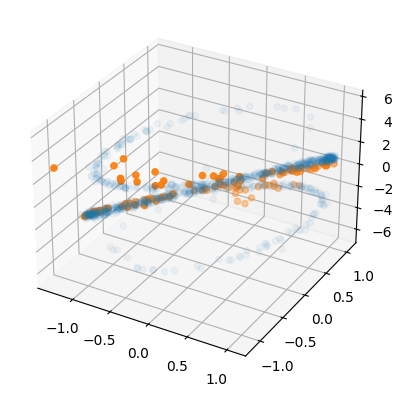

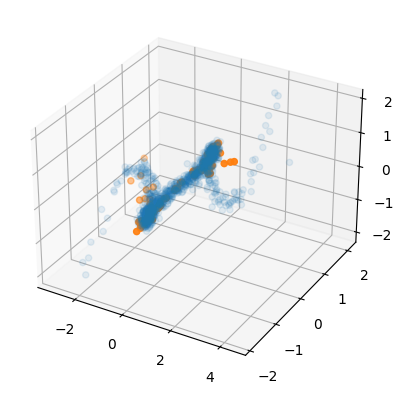

In [ ]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.scatter(samples[:,2], samples[:,3], samples[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.05)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
plt.show()

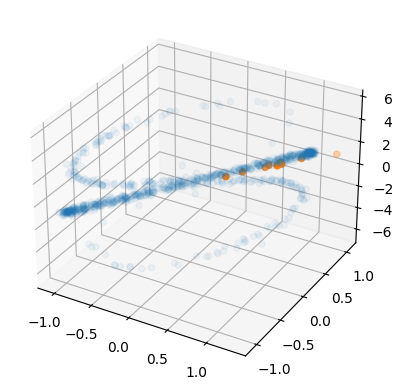

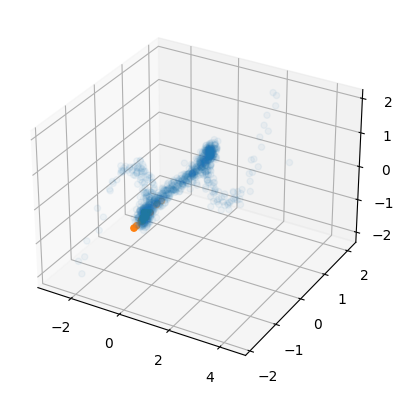

In [33]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.phy.nflow, 10, context)
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.scatter(samples[:,2], samples[:,3], samples[:,4])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.05)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

##### Standard RAE #####

In [14]:
# Construct RAE
epsilon = 0.1
d_epsilon = 1
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon)

0 | sigma = 56.94193649291992 with u = tensor([ 0.0369, -0.4102, -0.2123, -0.0993,  0.8806])
1 | sigma = 0.01966247893869877 with u = tensor([-0.2351, -0.0431, -0.9043, -0.2443, -0.2558])
2 | sigma = 0.0005046307924203575 with u = tensor([ 0.7419,  0.5369, -0.1672, -0.3372,  0.1406])
3 | sigma = 0.0003969889075960964 with u = tensor([-0.5848,  0.4466,  0.2297, -0.5976,  0.2206])
4 | sigma = 4.3297863157931715e-05 with u = tensor([-0.2258,  0.5850, -0.2375,  0.6780,  0.3011])
constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.00036177103174850345
0 | sigma = 56.94193649291992 with u = tensor([ 0.0369, -0.4102, -0.2123, -0.0993,  0.8806])
1 | sigma = 0.01966247893869877 with u = tensor([-0.2351, -0.0431, -0.9043, -0.2443, -0.2558])
2 | sigma = 0.0005046307924203575 with u = tensor([ 0.7419,  0.5369, -0.1672, -0.3372,  0.1406])
3 | sigma = 0.0003969889075960964 with u = tensor([-0.5848,  0.4466,  0.2297, -0.5976,  0.2206])
4 | sigma = 4.3297863157931715e-05 with u =

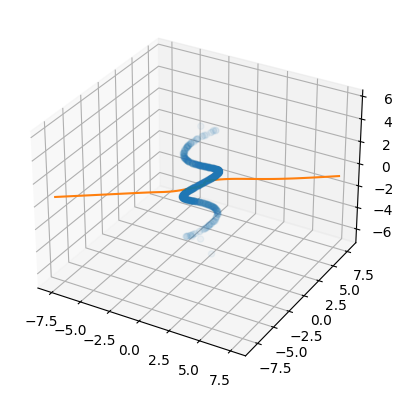

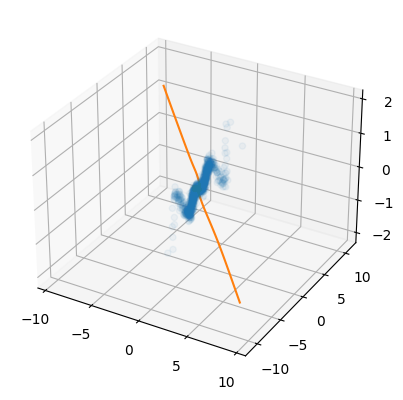

In [31]:
latent_geodesic = torch.linspace(- 5, 5, 100)[:,None]
geodesic = rae.decode(latent_geodesic).detach().cpu()
cor_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, geodesic) 

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.plot(geodesic[:,2].numpy(), geodesic[:,3].numpy(), geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.05)
ax.plot(cor_geodesic[:,0].numpy(), cor_geodesic[:,1].numpy(), cor_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(context[0], context[1], context[2])
plt.show()

##### Posterior RAE #####

In [16]:
rec_data_train = torch.zeros(data_train.shape[0], dim)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.phy.nflow, 10, context)
    rec_data_train[i] = samples.mean(0)

In [17]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train, 1)

0 | sigma = 235.85118103027344 with u = tensor([0.4526, 0.3892, 0.5221, 0.4480, 0.4127])
1 | sigma = 6.594268798828125 with u = tensor([ 0.0031,  0.5075,  0.0321,  0.2714, -0.8172])
2 | sigma = 0.8167329430580139 with u = tensor([-0.6868,  0.5370, -0.2554,  0.1757,  0.3792])
3 | sigma = 0.4010506570339203 with u = tensor([-0.5679, -0.3126,  0.7427,  0.1024, -0.1330])
4 | sigma = 0.25198590755462646 with u = tensor([-0.0300, -0.4526, -0.3310,  0.8272, -0.0194])
constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.03306082636117935


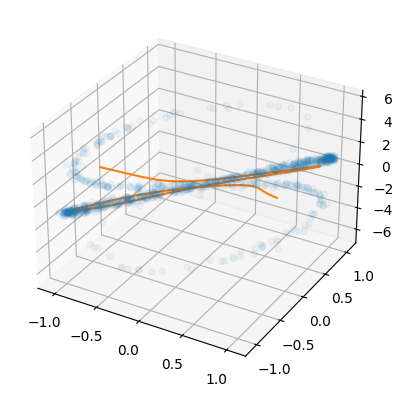

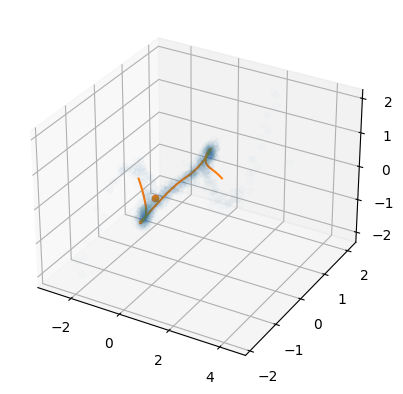

In [ ]:
latent_geodesic = torch.linspace(- 15, 15, 100)[:,None]
l2_tpca_geodesic = l2_tpca_rae.decode(latent_geodesic).detach().cpu()
cor_l2_tpca_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, l2_tpca_geodesic)

ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,2], data_clean[:,3], data_clean[:,4], alpha=0.05)
ax.plot(l2_tpca_geodesic[:,2].numpy(), l2_tpca_geodesic[:,3].numpy(), l2_tpca_geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.05)
ax.plot(cor_l2_tpca_geodesic[:,0].numpy(), cor_l2_tpca_geodesic[:,1].numpy(), cor_l2_tpca_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Reconstructing the data ###

In [19]:
# TODO implement the reconstruction module in the ambient flow class. Then after training, we should be able to compute the reconstructions and do error analysis